In [2]:
import pandas as pd

df = pd.read_csv('./Data/model_df_with_event_flag.csv')

# Time-based split: train on everything before 2025, test on 2025
model_df_clean = df[df['YEAR'] != 2020].copy()

train = model_df_clean[model_df_clean['YEAR'] < 2025].copy()
test = model_df_clean[model_df_clean['YEAR'] == 2025].copy()

print(f"Train: {len(train)} rows, Test: {len(test)} rows")
print(f"Train years: {sorted(train['YEAR'].unique())}")
print(f"Test years: {sorted(test['YEAR'].unique())}")

Train: 8059 rows, Test: 2207 rows
Train years: [np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Test years: [np.int64(2025)]


In [ ]:
test_event = test[test['event_flag'] == 1]
test_nonevent = test[test['event_flag'] == 0]

In [4]:
model_df_clean.isna().sum()

YEAR                  0
MONTH_NUM             0
DAY                   0
HOUR                  0
MONTH                 0
departure_count       0
arrival_count         0
within_count          0
avg_temp              0
avg_precip            0
date_str              0
event_date            0
day_of_week           0
event              9235
open_hour          9235
close_hour         9235
event_flag            0
dtype: int64

In [5]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

target = 'departure_count'

# --- Version 1: no weather (realistic forecasting scenario) ---
features_no_weather = ['HOUR', 'day_of_week', 'MONTH_NUM', 'YEAR', 'event_flag']

X_train_nw, y_train = train[features_no_weather], train[target]
X_test_nw, y_test = test[features_no_weather], test[target]

model_no_weather = xgb.XGBRegressor(objective='count:poisson', n_estimators=200, max_depth=5, learning_rate=0.05)
model_no_weather.fit(X_train_nw, y_train)

preds_no_weather = model_no_weather.predict(X_test_nw)
mae_no_weather = mean_absolute_error(y_test, preds_no_weather)
rmse_no_weather = root_mean_squared_error(y_test, preds_no_weather)

print("Without weather (realistic forecasting):")
print(f"  MAE:  {mae_no_weather:.1f}")
print(f"  RMSE: {rmse_no_weather:.1f}")

# --- Version 2: with weather (upper-bound, using realized weather) ---
features_with_weather = ['HOUR', 'day_of_week', 'MONTH_NUM', 'YEAR', 'event_flag', 'avg_temp', 'avg_precip']

X_train_w = train[features_with_weather]
X_test_w = test[features_with_weather]

model_with_weather = xgb.XGBRegressor(objective='count:poisson', n_estimators=200, max_depth=5, learning_rate=0.05)
model_with_weather.fit(X_train_w, y_train)

preds_with_weather = model_with_weather.predict(X_test_w)
mae_with_weather = mean_absolute_error(y_test, preds_with_weather)
rmse_with_weather = root_mean_squared_error(y_test, preds_with_weather)

print("\nWith weather (upper bound, using realized weather):")
print(f"  MAE:  {mae_with_weather:.1f}")
print(f"  RMSE: {rmse_with_weather:.1f}")

# --- Comparison ---
print(f"\nMAE improvement from weather: {mae_no_weather - mae_with_weather:.1f} ({(1 - mae_with_weather/mae_no_weather)*100:.1f}%)")
print(f"RMSE improvement from weather: {rmse_no_weather - rmse_with_weather:.1f} ({(1 - rmse_with_weather/rmse_no_weather)*100:.1f}%)")

Without weather (realistic forecasting):
  MAE:  139.2
  RMSE: 201.3

With weather (upper bound, using realized weather):
  MAE:  137.9
  RMSE: 197.0

MAE improvement from weather: 1.3 (0.9%)
RMSE improvement from weather: 4.3 (2.1%)


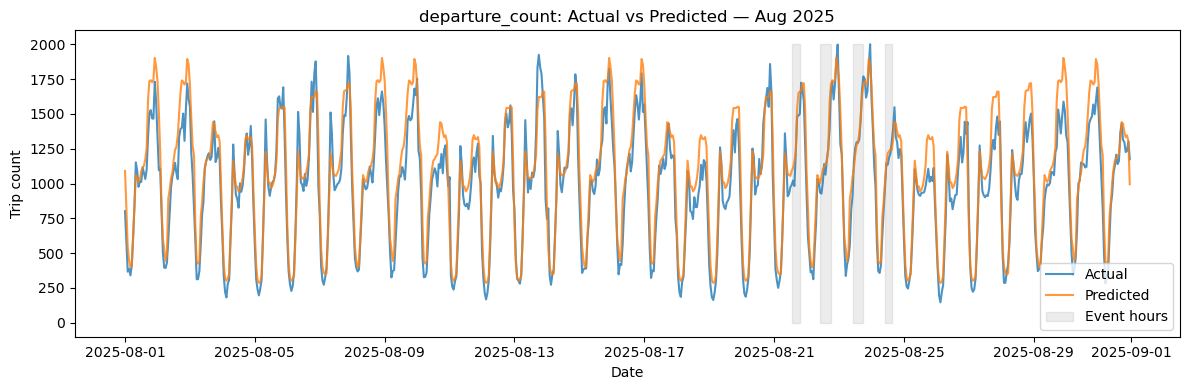

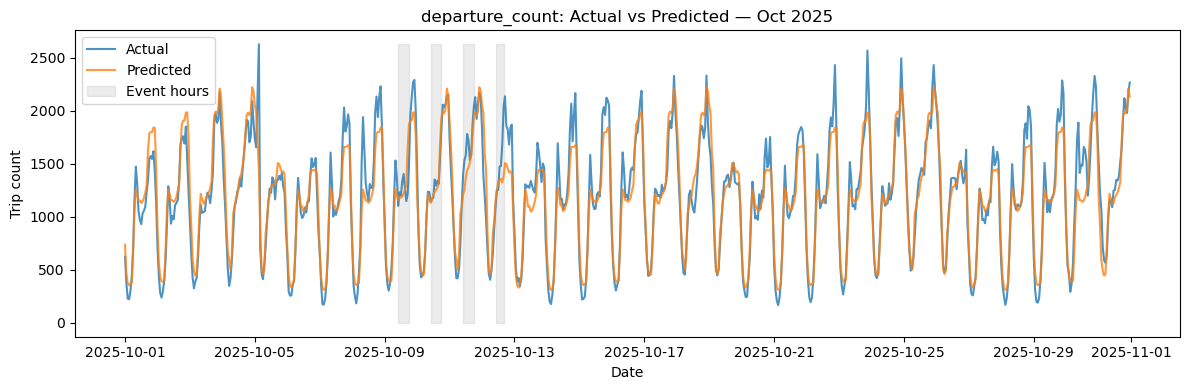

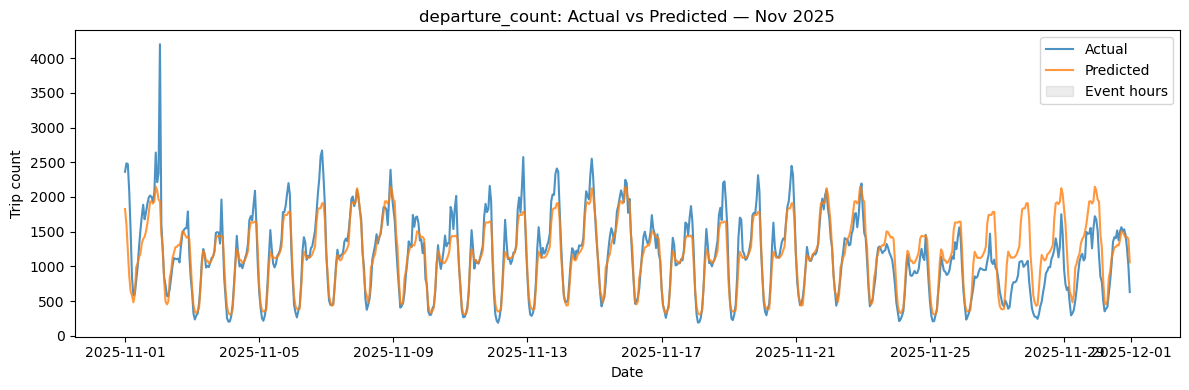

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

# Attach predictions back to the test set
test_plot = test.copy()
test_plot['predicted'] = preds_no_weather

test_plot['datetime'] = pd.to_datetime(
    test_plot[['YEAR', 'MONTH_NUM', 'DAY', 'HOUR']]
    .rename(columns={'YEAR': 'year', 'MONTH_NUM': 'month', 'DAY': 'day', 'HOUR': 'hour'})
)
test_plot = test_plot.sort_values('datetime')

# One figure per distinct (YEAR, MONTH_NUM) in the test set
combos = test_plot[['YEAR', 'MONTH_NUM', 'MONTH']].drop_duplicates().sort_values(['YEAR', 'MONTH_NUM'])

for _, row in combos.iterrows():
    yr, mnum, mname = row['YEAR'], row['MONTH_NUM'], row['MONTH']
    sub = test_plot[(test_plot['YEAR'] == yr) & (test_plot['MONTH_NUM'] == mnum)]

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(sub['datetime'], sub[target], label='Actual', color='tab:blue', alpha=0.8)
    ax.plot(sub['datetime'], sub['predicted'], label='Predicted', color='tab:orange', alpha=0.8)

    event_mask = sub['event_flag'] == 1
    ax.fill_between(sub['datetime'], 0, sub[target].max(),
                     where=event_mask, color='gray', alpha=0.15, label='Event hours')

    ax.set_title(f'{target}: Actual vs Predicted — {mname} {yr}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Trip count')
    ax.legend()
    plt.tight_layout()

    out_path = f'Data/plots/actual_vs_predicted_{yr}_{mname}.png'
    plt.savefig(out_path, dpi=150)
    plt.show()

In [13]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
import pandas as pd

features_no_weather = ['HOUR', 'day_of_week', 'MONTH_NUM', 'YEAR', 'event_flag']
target = 'departure_count'

years = sorted(model_df_clean['YEAR'].unique())

cv_results = []
all_fold_predictions = []

for test_year in years:
    train_fold = model_df_clean[model_df_clean['YEAR'] != test_year]
    test_fold = model_df_clean[model_df_clean['YEAR'] == test_year].copy()

    X_train_fold = train_fold[features_no_weather]
    y_train_fold = train_fold[target]
    X_test_fold = test_fold[features_no_weather]
    y_test_fold = test_fold[target]

    fold_model = xgb.XGBRegressor(objective='count:poisson', n_estimators=200, max_depth=5, learning_rate=0.05)
    fold_model.fit(X_train_fold, y_train_fold)

    fold_preds = fold_model.predict(X_test_fold)

    mae = mean_absolute_error(y_test_fold, fold_preds)
    rmse = root_mean_squared_error(y_test_fold, fold_preds)

    cv_results.append({'test_year': test_year, 'mae': mae, 'rmse': rmse, 'n_obs': len(test_fold)})

    test_fold['predicted'] = fold_preds
    all_fold_predictions.append(test_fold)

cv_results_df = pd.DataFrame(cv_results)
print(cv_results_df)
print(f"\nMean MAE across folds: {cv_results_df['mae'].mean():.1f} (± {cv_results_df['mae'].std():.1f})")
print(f"Mean RMSE across folds: {cv_results_df['rmse'].mean():.1f} (± {cv_results_df['rmse'].std():.1f})")

# Combine all fold predictions for plotting, same structure as your test_plot before
test_plot = pd.concat(all_fold_predictions, ignore_index=True)

   test_year         mae        rmse  n_obs
0       2019  354.507477  448.346619   1463
1       2021  344.160156  404.594940   1463
2       2022  223.873886  297.010376   1463
3       2023  149.710052  216.332458   1463
4       2024  131.773087  187.831940   2207
5       2025  139.173431  201.306885   2207

Mean MAE across folds: 223.9 (± 102.7)
Mean RMSE across folds: 292.6 (± 111.3)


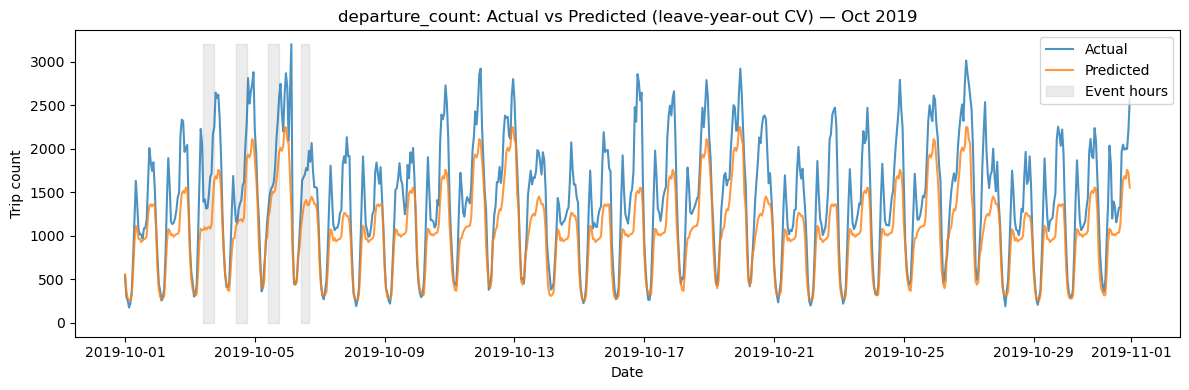

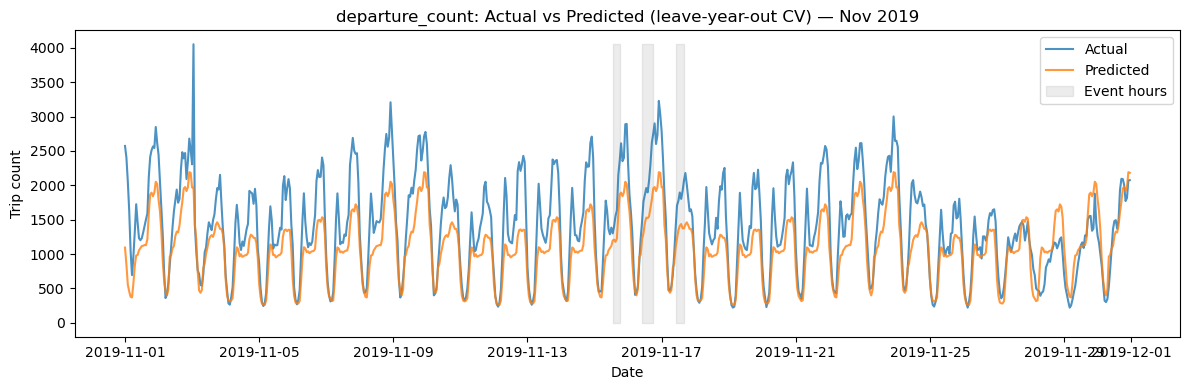

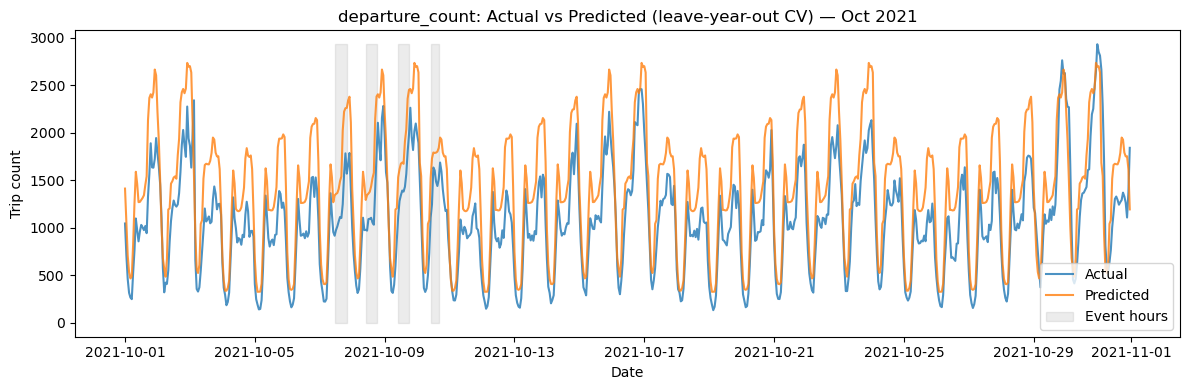

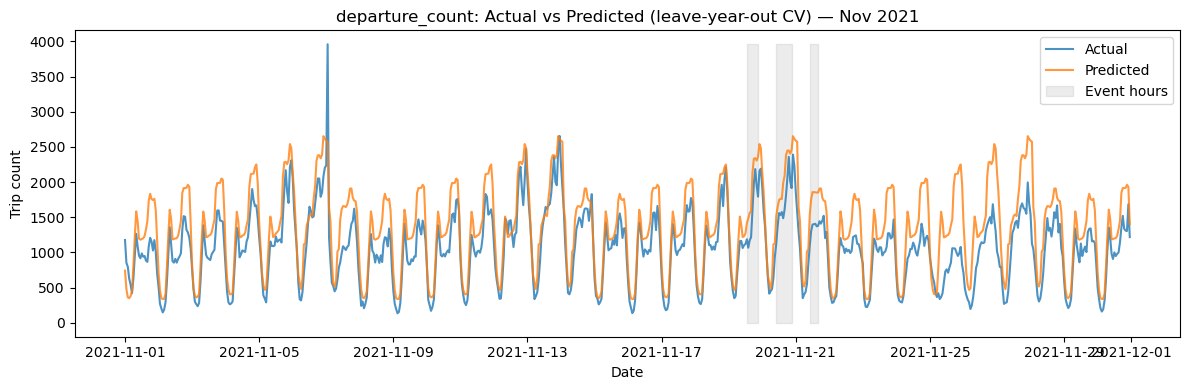

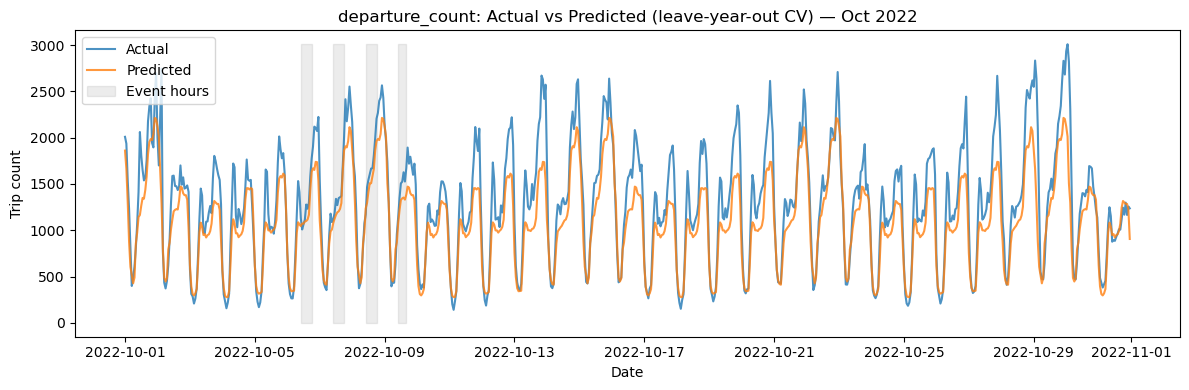

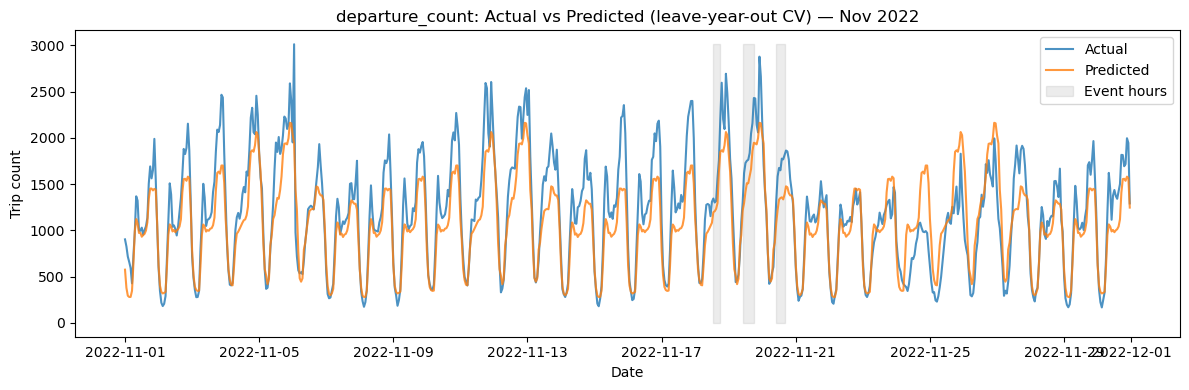

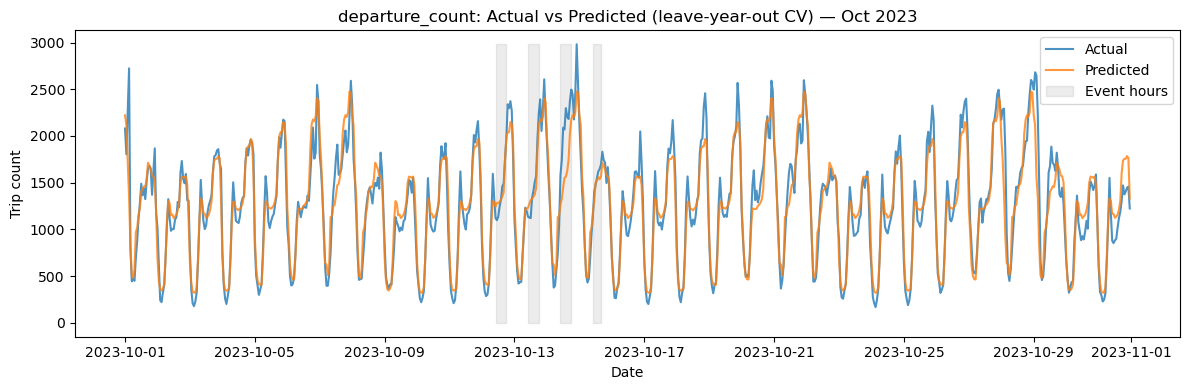

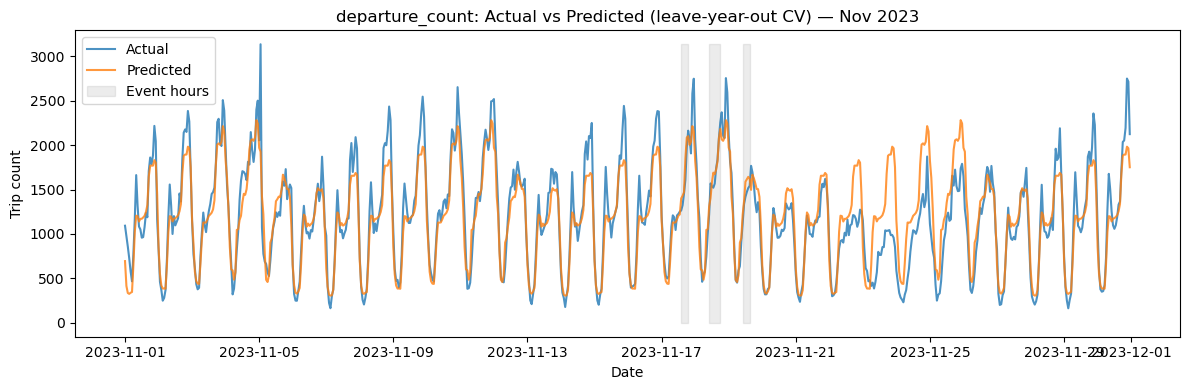

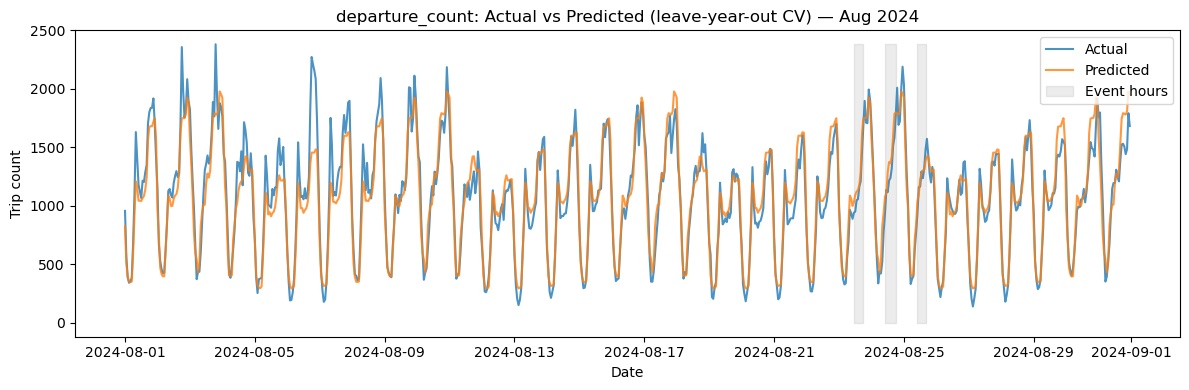

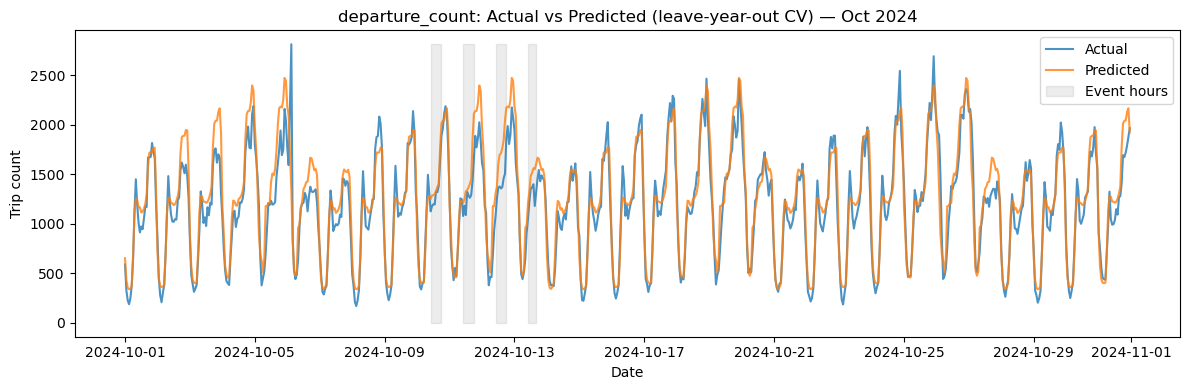

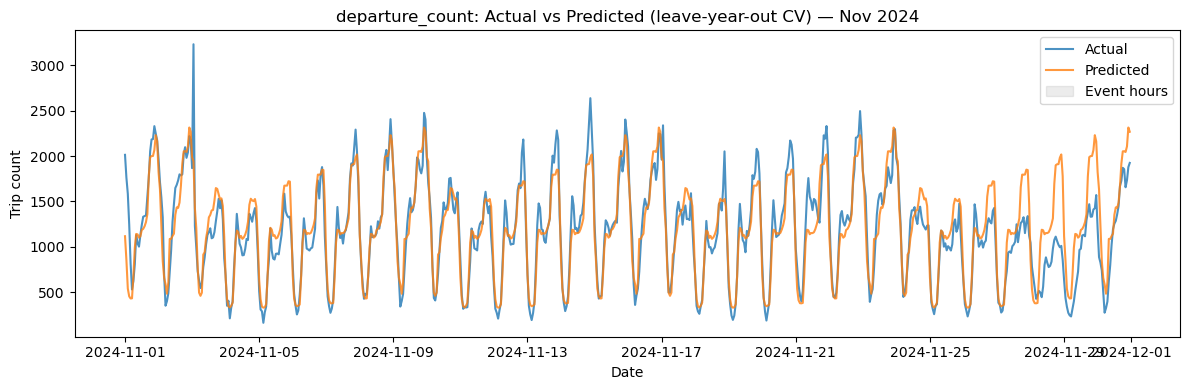

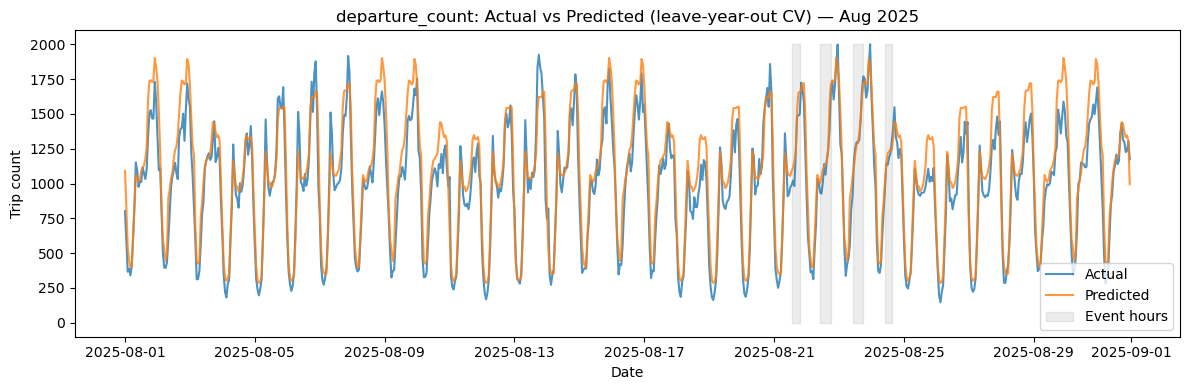

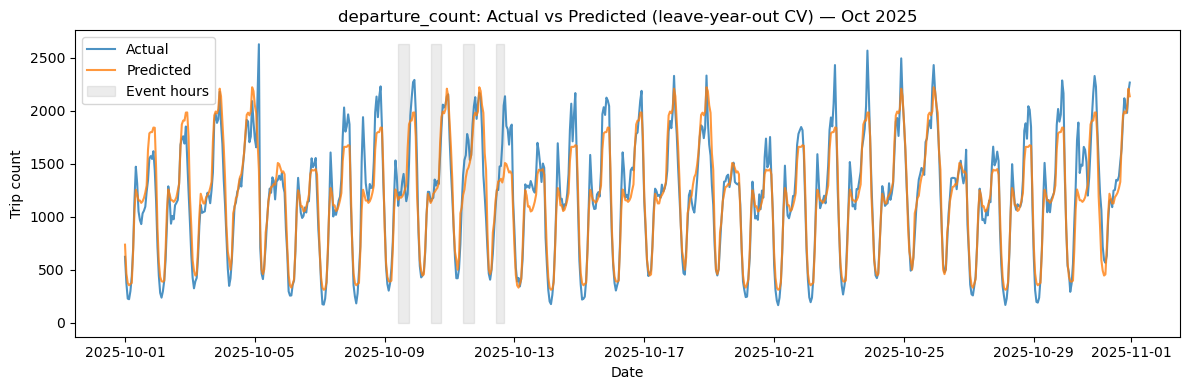

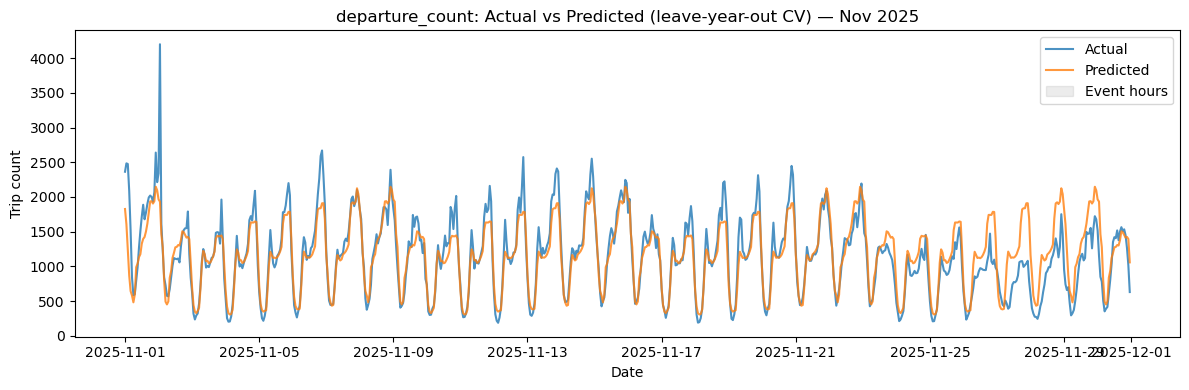

In [ ]:
test_plot['datetime'] = pd.to_datetime(
    test_plot[['YEAR', 'MONTH_NUM', 'DAY', 'HOUR']]
    .rename(columns={'YEAR': 'year', 'MONTH_NUM': 'month', 'DAY': 'day', 'HOUR': 'hour'})
)
test_plot = test_plot.sort_values('datetime')

combos = test_plot[['YEAR', 'MONTH_NUM', 'MONTH']].drop_duplicates().sort_values(['YEAR', 'MONTH_NUM'])

for _, row in combos.iterrows():
    yr, mnum, mname = row['YEAR'], row['MONTH_NUM'], row['MONTH']
    sub = test_plot[(test_plot['YEAR'] == yr) & (test_plot['MONTH_NUM'] == mnum)]

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(sub['datetime'], sub[target], label='Actual', color='tab:blue', alpha=0.8)
    ax.plot(sub['datetime'], sub['predicted'], label='Predicted', color='tab:orange', alpha=0.8)

    event_mask = sub['event_flag'] == 1
    ax.fill_between(sub['datetime'], 0, sub[target].max(),
                     where=event_mask, color='gray', alpha=0.15, label='Event hours')

    ax.set_title(f'{target}: Actual vs Predicted (leave-year-out CV) — {mname} {yr}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Trip count')
    ax.legend()
    plt.tight_layout()

    out_path = f'Data/plots/cv_actual_vs_predicted_{yr}_{mname}.png'
    plt.savefig(out_path, dpi=150)
    plt.show()
    plt.close(fig)

In [9]:
importance = pd.Series(model_no_weather.feature_importances_, index=features_no_weather).sort_values(ascending=False)
print(importance)

HOUR           0.586836
day_of_week    0.263100
YEAR           0.086910
event_flag     0.037144
MONTH_NUM      0.026010
dtype: float32


In [ ]:
import statsmodels.formula.api as smf
# evaluate a negative binomial GLM as a baseline model for comparison with XGBoost

formula = "departure_count ~ event_flag + avg_temp + avg_precip + C(MONTH, Treatment(reference='Nov')) + YEAR + C(HOUR) + C(day_of_week)"

nb_model_dep = smf.negativebinomial(formula, data=train).fit()

nb_preds = nb_model_dep.predict(test)
nb_mae = mean_absolute_error(test['departure_count'], nb_preds)
nb_rmse = root_mean_squared_error(test['departure_count'], nb_preds)
nb_r2 = r2_score(test['departure_count'], nb_preds)

print(f"NB GLM — MAE: {nb_mae:.1f}, RMSE: {nb_rmse:.1f}, R²: {nb_r2:.3f}")

         Current function value: 8.070004
         Iterations: 0
         Function evaluations: 13
         Gradient evaluations: 2
NB GLM — MAE: 227.4, RMSE: 304.8, R²: 0.651


/home/jovinguyen/miniconda3/envs/tf_env/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
/home/jovinguyen/miniconda3/envs/tf_env/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
/home/jovinguyen/miniconda3/envs/tf_env/lib/python3.12/site-packages/scipy/optimize/_optimize.py:1330: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(f, x0, args, fprime, callback=callback, **opts)
/home/jovinguyen/miniconda3/envs/tf_env/lib/python3.12/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/home/jovinguyen/miniconda3/envs/tf_env/lib/python3.12/si